In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, root_mean_squared_error
from utils.helpers import load_dataset, add_load_features
from utils.model_config import FORECAST_CONFIG

# Forecast

This notebook was used to establish the base workflow of training an XGBoost nowcasting model.

# Load data

In [3]:
project_root = Path.cwd().parent.parent.parent
interval = 60
horizon = 6
multiplier = 4 if interval == 15 else 1

path = project_root / f"data/time_series_{interval}.csv"
df = load_dataset(path)

# Extract each country column into separate DataFrame,
### remove outliers and create forecast target variable

In [4]:
countries = set([c[:2].upper() for c in df.columns if "timestamp" not in c])
countries_data = {}

for c in countries:
    target = f"{c}_load_actual_entsoe_transparency"
    df_c = pd.DataFrame(df[target])

    Q3 = df_c[target].quantile(0.75)
    upper_bound = 2.5*Q3
    mask = (df_c[target] > upper_bound)

    if mask.sum() > 0:
        print(f"Removing {mask.sum()} outliers from {c} dataset.")
        df_c = df_c[~mask]

    df_c = add_load_features(df_c, target, interval, type="forecast")
    df_c["target_forecast"] = df_c[target].shift(-1 * horizon * multiplier)
    mask_valid_target = df_c["target_forecast"].notna() # Extract rows where target is valid (not null)
    df_c = df_c[mask_valid_target].copy() # Take into DataFrame only rows with valid target
    countries_data[c] = df_c

for idx, c in enumerate(countries_data):
    if not idx % 5:
        print(f"{c} shape: {countries_data[c].shape}")

Removing 1 outliers from FR dataset.
Removing 10 outliers from SK dataset.
Removing 1 outliers from CH dataset.
AT shape: (50395, 29)
GB shape: (50389, 29)
BG shape: (50332, 29)
NL shape: (50395, 29)
DE shape: (50395, 29)
DK shape: (50394, 29)
PL shape: (50394, 29)


# Create training data for each country

In [5]:
model_data = {}

for c in countries:
    target = f"{c}_load_actual_entsoe_transparency"
    df_c = countries_data[c]
    X = df_c.drop([target, "target_forecast"], axis=1).to_numpy()
    y = df_c["target_forecast"].to_numpy()
    model_data[c] = {"X": X, "y": y}

for idx, key in enumerate(model_data):
    if not idx % 5:
        print(f"{key} || X: {model_data[key]['X'].shape}, y: {model_data[key]['y'].shape}")

AT || X: (50395, 27), y: (50395,)
GB || X: (50389, 27), y: (50389,)
BG || X: (50332, 27), y: (50332,)
NL || X: (50395, 27), y: (50395,)
DE || X: (50395, 27), y: (50395,)
DK || X: (50394, 27), y: (50394,)
PL || X: (50394, 27), y: (50394,)


# Model training

In [7]:
models = {}
gap_multiplier = 4 if interval == 15 else 1
gap = 168 * gap_multiplier
val_size = 168 * gap_multiplier

for idx, country in enumerate(model_data):

    X, y = model_data[country]["X"], model_data[country]["y"]

    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]
    X_train, y_train = X_train_full[:-val_size - gap], y_train_full[:-val_size - gap]

    params = FORECAST_CONFIG[interval][horizon]
    model_c = xgb.XGBRegressor(**params)

    model_c.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    if not idx % 5:
        n_estimators_used = model_c.best_iteration + 1
        final_rmse = model_c.best_score
        print(f"----- Training {country} model -----")
        print(f"Number of estimators: {n_estimators_used}")
        print(f"Final RMSE: {final_rmse:.4f}")

    models[country] = model_c

----- Training AT model -----
Number of estimators: 361
Final RMSE: 121.9202
----- Training GB model -----
Number of estimators: 178
Final RMSE: 1134.8780
----- Training BG model -----
Number of estimators: 402
Final RMSE: 90.2523
----- Training NL model -----
Number of estimators: 163
Final RMSE: 325.5349
----- Training DE model -----
Number of estimators: 538
Final RMSE: 1315.4743
----- Training DK model -----
Number of estimators: 373
Final RMSE: 52.7626
----- Training PL model -----
Number of estimators: 241
Final RMSE: 267.4249


# Evaluate models on test data

In [9]:
for idx, country in enumerate(model_data):

    if not idx % 5:
        X, y = model_data[country]["X"], model_data[country]["y"]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        model_c = models[country]

        y_pred = model_c.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)*100
        r2 = r2_score(y_test, y_pred)

        print(f'{country} model || Test RMSE: {rmse} MAPE: {mape:.3f}%, R2: {r2:.4f}')

AT model || Test RMSE: 242.5603154802331 MAPE: 2.577%, R2: 0.9693
GB model || Test RMSE: 2763.958954062966 MAPE: 7.373%, R2: 0.8734
BG model || Test RMSE: 151.01926274859673 MAPE: 2.909%, R2: 0.9649
NL model || Test RMSE: 760.5732498874117 MAPE: 4.466%, R2: 0.8461
DE model || Test RMSE: 1721.2367006936463 MAPE: 2.460%, R2: 0.9694
DK model || Test RMSE: 127.52042123065945 MAPE: 2.309%, R2: 0.9670
PL model || Test RMSE: 497.93977012059884 MAPE: 1.929%, R2: 0.9746


# Plot random test set time series

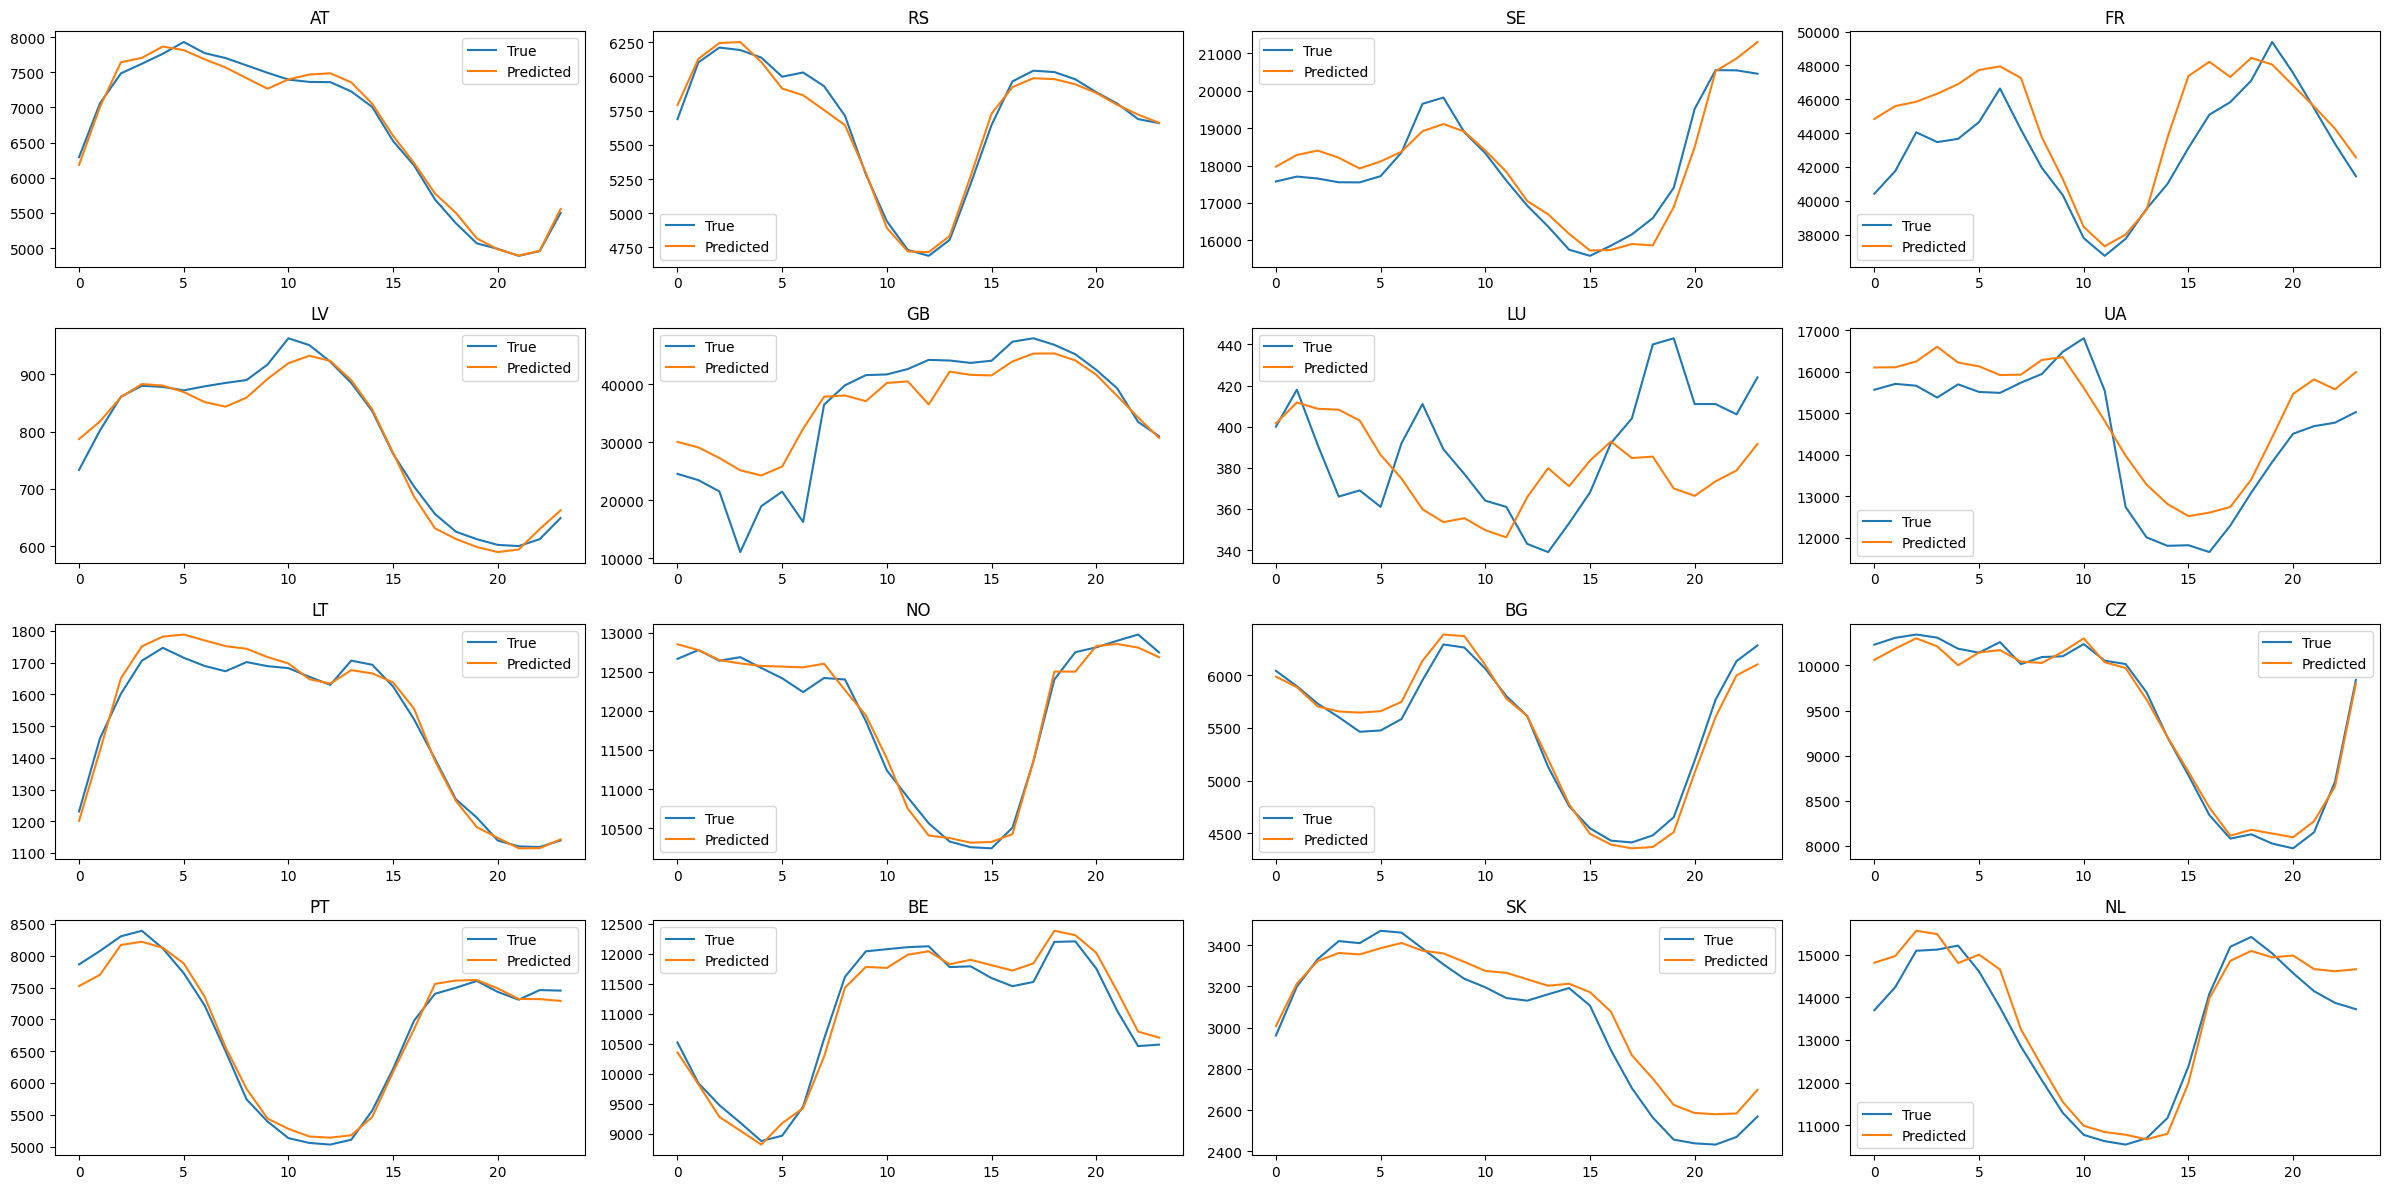

In [11]:
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(24, 12))
ax = ax.flatten()

for i, country in enumerate(list(countries)[:16]):

    X, y = model_data[country]["X"], model_data[country]["y"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model_c = models[country]

    window = 24
    idx = np.random.randint(0, len(X_test) - window)

    y_pred = model_c.predict(X_test[idx:idx+window])

    ax[i].plot(range(len(X_test[idx:idx+window])), y_test[idx:idx+window], label="True")
    ax[i].plot(range(len(X_test[idx:idx+window])), y_pred, label="Predicted")
    ax[i].set_title(country)
    ax[i].legend()

plt.tight_layout()
plt.show()

# Forecast 60min +6h

| Country | n_estimators | Train RMSE | Test RMSE | Test MAPE | Test R² |
|---------|-------------:|-----------:|----------:|-----:|---:|
| AT | 361 | 121.920 | 242.560 | 2.577 | 0.9693 |
| BE | 177 | 189.725 | 384.043 | 3.232 | 0.9162 |
| BG | 402 | 90.252 | 151.019 | 2.909 | 0.9649 |
| CH | 675 | 419.707 | 362.539 | 4.203 | 0.8499 |
| CY | 298 | 17.423 | 49.788 | 9.323 | 0.8719 |
| CZ | 1263 | 92.599 | 177.132 | 1.925 | 0.9817 |
| DE | 538 | 1315.474 | 1721.237 | 2.460 | 0.9694 |
| DK | 373 | 52.763 | 127.520 | 2.309 | 0.9670 |
| EE | 122 | 21.297 | 34.898 | 2.947 | 0.9638 |
| ES | 339 | 575.422 | 1213.893 | 3.422 | 0.9321 |
| FI | 796 | 112.090 | 234.879 | 2.069 | 0.9675 |
| FR | 186 | 626.099 | 1724.804 | 2.748 | 0.9747 |
| GB | 178 | 1134.878 | 2763.959 | 7.373 | 0.8734 |
| GR | 336 | 181.936 | 251.902 | 3.475 | 0.9520 |
| HR | 368 | 76.236 | 72.958 | 2.841 | 0.9624 |
| HU | 277 | 108.987 | 180.688 | 2.774 | 0.9399 |
| IE | 850 | 66.658 | 102.388 | 2.146 | 0.9727 |
| IT | 576 | 710.572 | 1476.132 | 3.487 | 0.9608 |
| LT | 409 | 22.456 | 38.588 | 2.051 | 0.9755 |
| LU | 335 | 34.494 | 58.092 | 12.605 | 0.6468 |
| LV | 462 | 13.766 | 22.044 | 1.968 | 0.9807 |
| ME | 252 | 12.764 | 16.858 | 3.285 | 0.9478 |
| NL | 163 | 325.535 | 760.573 | 4.466 | 0.8461 |
| NO | 620 | 170.526 | 392.366 | 1.837 | 0.9817 |
| PL | 241 | 267.425 | 497.940 | 1.929 | 0.9746 |
| PT | 174 | 77.383 | 201.186 | 2.715 | 0.9615 |
| RO | 455 | 117.347 | 201.022 | 2.357 | 0.9613 |
| RS | 1600 | 134.328 | 135.682 | 2.279 | 0.9761 |
| SE | 619 | 203.955 | 505.987 | 2.530 | 0.9720 |
| SI | 547 | 84.159 | 66.893 | 3.725 | 0.9404 |
| SK | 238 | 61.253 | 131.344 | 3.161 | 0.9302 |
| UA | 527 | 450.286 | 761.905 | 4.079 | 0.8108 |

# Forecast 60min +12h

| Country | n_estimators | Train RMSE | Test RMSE | Test MAPE | Test R² |
|---------|-------------:|-----------:|----------:|-----:|---:|
| AT | 183 | 168.648 | 304.145 | 3.000 | 0.9517 |
| BE | 139 | 197.944 | 453.422 | 3.608 | 0.8832 |
| BG | 328 | 98.434 | 156.198 | 2.775 | 0.9624 |
| CH | 506 | 519.530 | 384.226 | 4.390 | 0.8314 |
| CY | 173 | 16.722 | 52.020 | 8.845 | 0.8602 |
| CZ | 442 | 101.933 | 199.524 | 2.019 | 0.9768 |
| DE | 423 | 1433.758 | 2008.790 | 2.711 | 0.9583 |
| DK | 456 | 49.338 | 140.181 | 2.424 | 0.9601 |
| EE | 105 | 19.935 | 37.737 | 3.007 | 0.9577 |
| ES | 323 | 550.260 | 1242.242 | 3.121 | 0.9289 |
| FI | 290 | 118.084 | 294.350 | 2.512 | 0.9489 |
| FR | 221 | 819.897 | 2095.127 | 2.938 | 0.9627 |
| GB | 79 | 1175.141 | 2777.979 | 7.477 | 0.8721 |
| GR | 237 | 236.055 | 262.649 | 3.462 | 0.9478 |
| HR | 338 | 98.668 | 79.916 | 2.793 | 0.9549 |
| HU | 384 | 117.495 | 197.968 | 2.831 | 0.9279 |
| IE | 369 | 83.586 | 106.192 | 2.108 | 0.9706 |
| IT | 219 | 970.709 | 1842.969 | 3.849 | 0.9388 |
| LT | 184 | 25.960 | 41.937 | 2.103 | 0.9710 |
| LU | 474 | 34.928 | 62.381 | 13.656 | 0.5928 |
| LV | 161 | 14.719 | 24.275 | 2.010 | 0.9766 |
| ME | 221 | 12.949 | 18.149 | 3.295 | 0.9395 |
| NL | 117 | 330.566 | 731.099 | 3.915 | 0.8578 |
| NO | 387 | 187.376 | 472.622 | 2.243 | 0.9735 |
| PL | 215 | 290.858 | 626.712 | 2.101 | 0.9597 |
| PT | 125 | 74.756 | 206.062 | 2.503 | 0.9596 |
| RO | 446 | 145.177 | 214.390 | 2.344 | 0.9560 |
| RS | 817 | 162.740 | 151.339 | 2.407 | 0.9702 |
| SE | 327 | 228.264 | 613.294 | 2.999 | 0.9589 |
| SI | 101 | 100.841 | 75.557 | 4.157 | 0.9240 |
| SK | 192 | 68.076 | 126.312 | 2.783 | 0.9355 |
| UA | 63 | 482.153 | 880.424 | 5.093 | 0.7474 |

# Forecast 60min +24h

| Country | n_estimators | Train RMSE | Test RMSE | Test MAPE | Test R² |
|---------|-------------:|-----------:|----------:|-----:|---:|
| AT | 194 | 147.497 | 315.594 | 3.107 | 0.9480 |
| BE | 142 | 164.575 | 407.304 | 3.312 | 0.9057 |
| BG | 161 | 100.258 | 169.420 | 2.946 | 0.9558 |
| CH | 480 | 568.902 | 418.287 | 4.729 | 0.8002 |
| CY | 118 | 18.965 | 45.038 | 7.613 | 0.8952 |
| CZ | 148 | 119.964 | 235.436 | 2.330 | 0.9678 |
| DE | 236 | 1134.294 | 2109.424 | 2.871 | 0.9540 |
| DK | 396 | 54.126 | 145.476 | 2.556 | 0.9570 |
| EE | 193 | 17.746 | 35.155 | 2.878 | 0.9633 |
| ES | 148 | 711.701 | 1194.340 | 3.117 | 0.9342 |
| FI | 121 | 120.199 | 321.039 | 2.716 | 0.9392 |
| FR | 149 | 731.262 | 2200.296 | 3.132 | 0.9589 |
| GB | 73 | 1071.506 | 2348.887 | 6.182 | 0.9086 |
| GR | 133 | 264.225 | 275.078 | 3.712 | 0.9427 |
| HR | 575 | 115.927 | 81.193 | 2.994 | 0.9535 |
| HU | 245 | 117.141 | 198.449 | 2.918 | 0.9276 |
| IE | 941 | 71.451 | 107.679 | 2.222 | 0.9698 |
| IT | 139 | 1090.183 | 1748.010 | 3.877 | 0.9450 |
| LT | 236 | 26.395 | 41.656 | 2.138 | 0.9714 |
| LU | 213 | 39.992 | 64.079 | 13.902 | 0.5704 |
| LV | 312 | 12.779 | 24.287 | 2.083 | 0.9766 |
| ME | 395 | 13.355 | 18.443 | 3.453 | 0.9375 |
| NL | 210 | 300.580 | 658.098 | 3.584 | 0.8848 |
| NO | 232 | 214.086 | 571.269 | 2.638 | 0.9613 |
| PL | 180 | 340.466 | 666.454 | 2.299 | 0.9544 |
| PT | 93 | 78.394 | 220.786 | 2.687 | 0.9536 |
| RO | 208 | 168.321 | 220.144 | 2.450 | 0.9536 |
| RS | 49 | 169.914 | 179.786 | 3.127 | 0.9580 |
| SE | 254 | 242.509 | 673.683 | 3.233 | 0.9504 |
| SI | 454 | 75.131 | 72.620 | 4.048 | 0.9298 |
| SK | 695 | 66.579 | 124.172 | 2.704 | 0.9376 |
| UA | 49 | 430.577 | 705.166 | 4.028 | 0.8380 |